In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 1200,
})

import yaml
import numpy as np

import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

from irc.manager import IRCManager

from auditoryforage.utils import plot_AF_episode

/home/lokesh/anaconda3/envs/IRC/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from auditoryforage.AF_env import AuditoryForaging
env = AuditoryForaging()

In [3]:
from read_data import DataToEpisode

In [4]:
filename = f'./data_flies/compiled/compiled.csv'

# end_trial = 50
# data_to_episode = DataToEpisode(filename = filename, env = env, end_trial = end_trial)
data_to_episode = DataToEpisode(filename = filename, env = env)

In [5]:
data_IRC = data_to_episode.data_for_IRC()

start list is [0, 3845, 6380, 7234, 7381, 7572] and stop list is [3716, 6240, 7085, 7253, 7430, 11634]
start list is [0, 282, 427, 1505, 1663, 2098, 2273, 2780, 3044, 3566, 3801, 4031] and stop list is [166, 312, 1359, 1518, 1978, 2126, 2642, 2904, 3453, 3677, 3897, 4142]
start list is [0, 351] and stop list is [206, 13855]
start list is [0, 1675, 1873, 2105, 2782, 2941, 3168, 4094, 4360, 4576, 5068, 5193, 5374, 5669] and stop list is [1550, 1731, 1975, 2649, 2810, 3020, 3955, 4233, 4432, 4932, 5085, 5258, 5533, 6778]
start list is [0, 665, 1418, 8936, 9137, 15518] and stop list is [550, 1293, 8797, 9022, 15371, 16167]
start list is [0, 3532, 3658, 3832, 3953, 4714, 5435, 5608] and stop list is [3390, 3536, 3690, 3835, 4592, 5291, 5488, 5640]
start list is [0, 14652] and stop list is [14507, 14966]
start list is [0, 9125, 9268] and stop list is [8979, 9147, 9347]


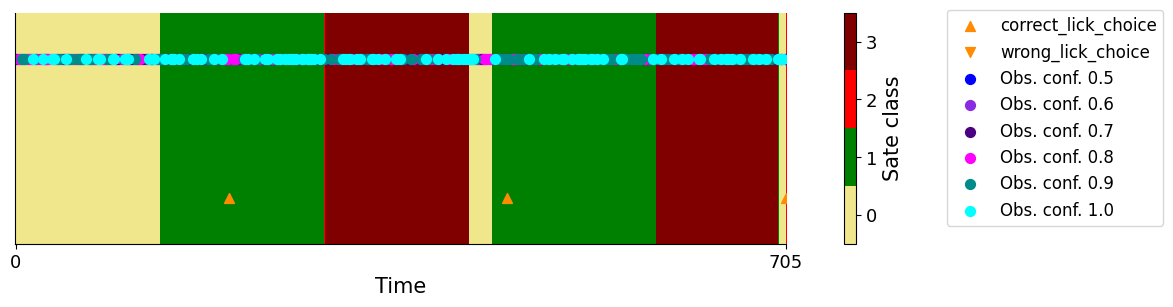

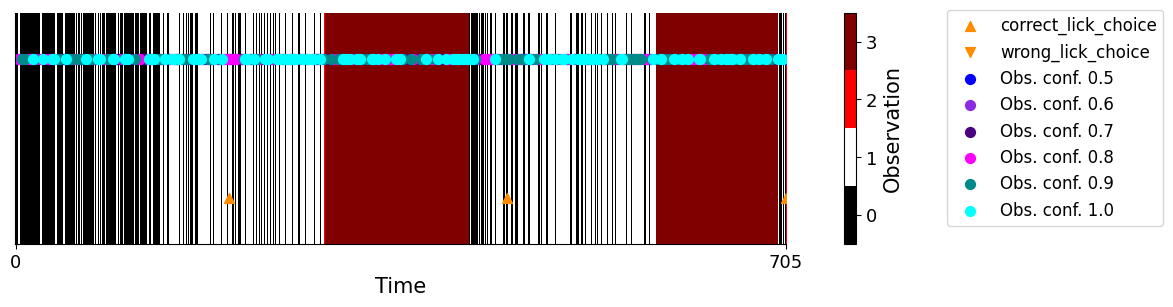

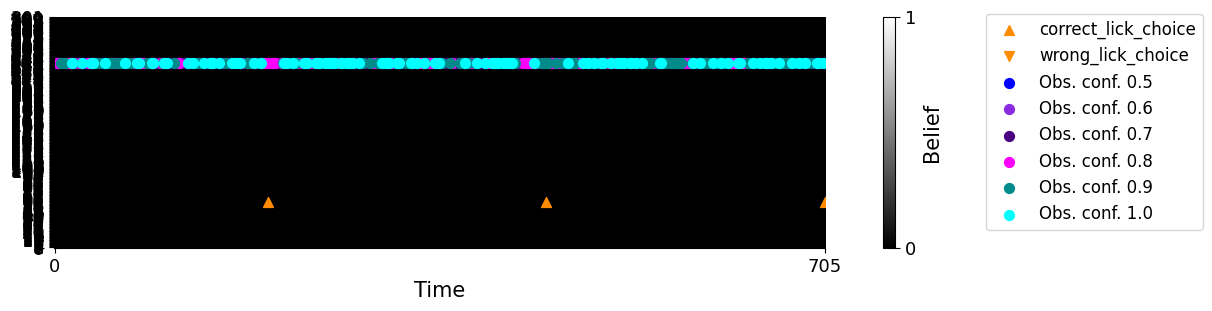

In [6]:
exp_dict = data_IRC['low_reward_blocks']['episodes'][0][2]
episode = {}
episode['states'] = exp_dict['states']
episode['actions'] = exp_dict['actions']
episode['observations'] = exp_dict['observations']
episode['num_steps'] = len(exp_dict['actions'])

# wrong info
episode['rewards'] = exp_dict['received_food'] # does not incorporate other costs
episode['q_probs'] = np.zeros((len(episode['states'])+1,302)) # all set to 0 temporarily

fig = plot_AF_episode(episode = episode, env = env, agent = None)

In [7]:
np.where(exp_dict['states'].flatten() == [151])

(array([705]),)

(array([166]),)
167


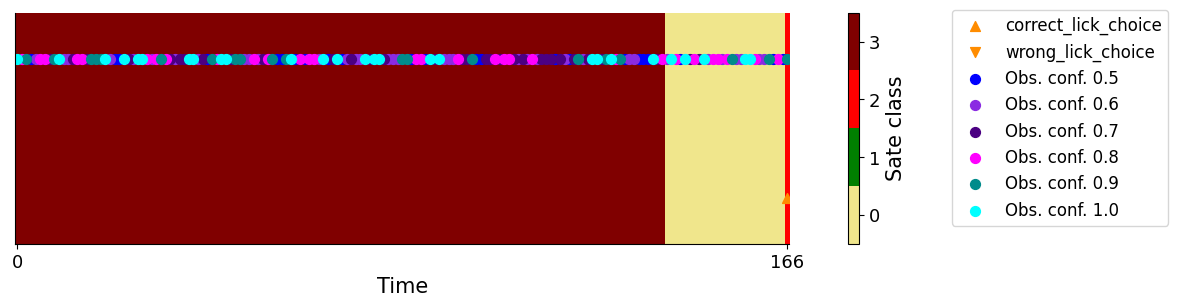

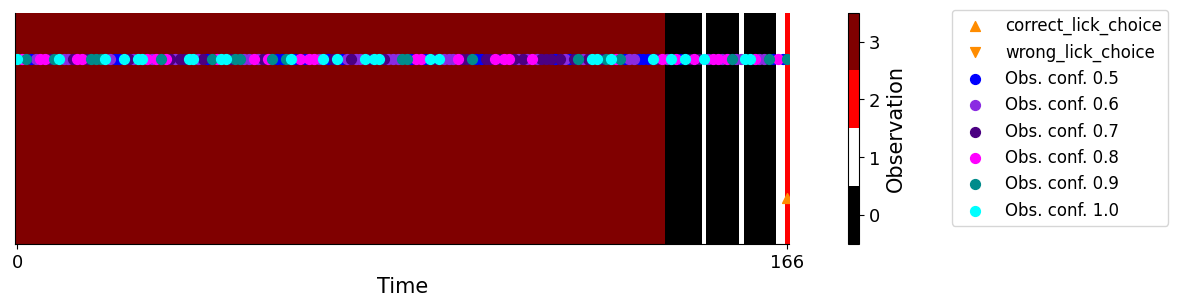

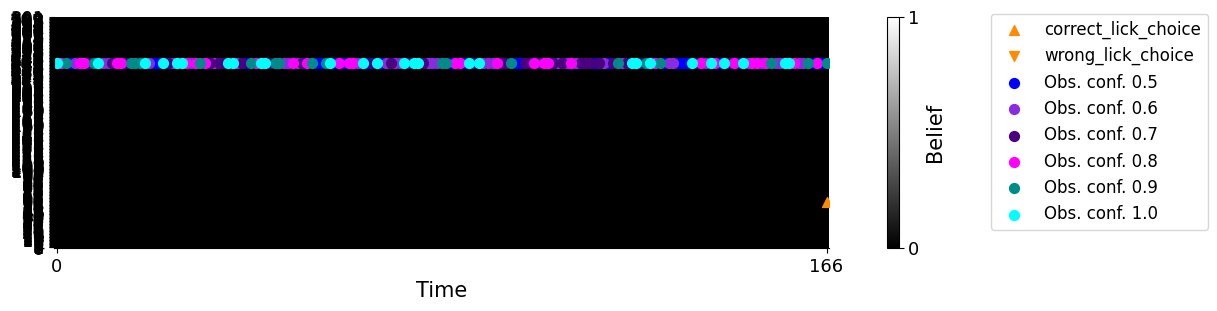

In [18]:
exp_dict = data_IRC['high_reward_blocks']['episodes'][0][0]
episode = {}
episode['states'] = exp_dict['states']
episode['actions'] = exp_dict['actions']
episode['observations'] = exp_dict['observations']
episode['num_steps'] = len(exp_dict['actions'])

# wrong info
episode['rewards'] = exp_dict['received_food'] # does not incorporate other costs
episode['q_probs'] = np.zeros((len(episode['states'])+1,302)) # all set to 0 temporarily

fig = plot_AF_episode(episode = episode, env = env, agent = None)

print(np.where(exp_dict['states'].flatten() == [151]))
print(len(exp_dict['states']))